# Smooth response to parameter extensions

This notebook makes the demonstration plots for the extended cosmological-parameter space. Starting from the DQ2 fiducial cosmology, it varies one extension parameter at a time and plots the response of the matter power spectrum, the real-space correlation function $\xi(r)$, and the Limber lensing $C_\ell$.

All curves keep $A_s$ fixed. When $M_\nu$, $w_0$, $w_a$, $\Omega_K$, or the combined scenarios are changed, dependent quantities such as $\omega_{\rm cdm}$, $\Omega_{\rm de}$, and $\sigma_8$ are recomputed through `set_param()`.

The DESI-like curves use the marginalized posterior means from Table V in Abdul Karim et al. (DESI Collaboration), [DESI DR2 results. II](https://doi.org/10.1103/tr6y-kpc6), Phys. Rev. D 112, 083515 (2025). The five choices are $\Lambda{\rm CDM}$ from DESI+CMB, $o\Lambda{\rm CDM}$ from DESI alone, $w_0{\rm CDM}$ from DESI+CMB+Pantheon+, $w_0w_a{\rm CDM}$ from DESI+CMB+Pantheon+, and $ow_0w_a{\rm CDM}$ from DESI+CMB+Pantheon+. Parameters not quoted in the selected Table V row, including $M_\nu$, are kept fixed to the DQ2 fiducial cosmology. The two CPL DESI-like choices use `strict=False` because their Table V posterior means have $w_a<-0.5$, just outside the nominal DQ2 one-parameter sweep range.

The DESI-like parameter table is shown before the plots. The parameter-sweep panels $(a)$--$(d)$ and the DESI-like scenario panels are plotted as separate figures for each statistic. The lower rows show fiducial ratios for $P(k)$ and $C_\ell$, and a BAO-scale zoom for $r^2\xi(r)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from dark_emulator2 import DarkEmulator2 as dq2

In [2]:
n_param_samples = 40

param_panels = [
    (r"$M_\nu$", "Mnu", np.linspace(0.0, 0.50, n_param_samples)),
    (r"$w_0$", "w0", np.linspace(-1.5, -0.5, n_param_samples)),
    (r"$w_a$", "wa", np.linspace(-0.5, 0.5, n_param_samples)),
    (r"$\Omega_K$", "Omega_k", np.linspace(-0.1, 0.1, n_param_samples)),
]

# DESI-like values: Table V of DESI DR2 BAO Results II.
# Values not quoted in the selected row are kept fixed to the DQ2 fiducial cosmology.
# The table gives H0 in km/s/Mpc and 10^3 Omega_K; here h0=H0/100.
scenario_panels = [
    ("fiducial", {}, True),
    (r"DESI $\Lambda{\rm CDM}$", {"Omega_m": 0.3027, "h0": 0.6817}, True),
    (r"DESI $o\Lambda{\rm CDM}$", {"Omega_m": 0.293, "Omega_k": 0.025}, True),
    (r"DESI $w_0{\rm CDM}$", {"Omega_m": 0.3047, "h0": 0.6797, "w0": -0.995}, True),
    (r"DESI $w_0w_a{\rm CDM}$", {"Omega_m": 0.3114, "h0": 0.6751, "w0": -0.838, "wa": -0.62}, False),
    (r"DESI $ow_0w_a{\rm CDM}$", {"Omega_m": 0.3117, "h0": 0.6762, "Omega_k": 0.0011, "w0": -0.853, "wa": -0.54}, False),
]

panel_labels = ("(a)", "(b)", "(c)", "(d)")
scenario_colors = ("k", "#0072B2", "#D62728", "#009E73", "#E69F00", "#6A3D9A")
scenario_linestyles = ("-", "-", "-", (0, (7, 2.0)), (0, (3, 1.3)), (0, (7, 1.5, 1.5, 1.5)))
param_cmap = cm.turbo

param_figure_size = (13.5, 5.5)
scenario_figure_size = (7.2, 5.5)
ratio_ylim = (0.5, 1.5)
pk_scenario_ratio_ylim = (0.8, 1.2)
cl_scenario_ratio_ylim = (0.7, 1.3)

#save_pdf = False
save_pdf = True

### DESI-like scenario parameters

Bold entries are changed from the DQ2 fiducial cosmology. Other entries are kept fixed to the DQ2 fiducial values.

| model | constraint | $\Omega_m$ | $h$ | $\Omega_K$ | $w_0$ | $w_a$ | $M_\nu$ [eV] |
| --- | --- | --- | --- | --- | --- | --- | --- |
| fiducial | DQ2 fiducial | 0.3156 | 0.67235 | 0 | -1 | 0 | 0.06 |
| DESI $\Lambda{\rm CDM}$ | DESI+CMB | **0.3027** | **0.6817** | 0 | -1 | 0 | 0.06 |
| DESI $o\Lambda{\rm CDM}$ | DESI | **0.293** | 0.67235 | **0.025** | -1 | 0 | 0.06 |
| DESI $w_0{\rm CDM}$ | DESI+CMB+Pantheon+ | **0.3047** | **0.6797** | 0 | **-0.995** | 0 | 0.06 |
| DESI $w_0w_a{\rm CDM}$ | DESI+CMB+Pantheon+ | **0.3114** | **0.6751** | 0 | **-0.838** | **-0.62** | 0.06 |
| DESI $ow_0w_a{\rm CDM}$ | DESI+CMB+Pantheon+ | **0.3117** | **0.6762** | **0.0011** | **-0.853** | **-0.54** | 0.06 |

In [3]:
emu = dq2()

def set_demo_param(strict=True, **updates):
    p = emu.param.get_fid_param()
    p.update(updates)

    emu.param.clear_sigma8(p)
    emu.param.clear_lnAs(p)
    emu.param.clear_omega_cdm(p)
    emu.param.clear_Omega_de(p)

    return emu.param.set_param(p, strict=strict)

fid = set_demo_param()

def param_line_style(color):
    return {"color": color, "lw": 0.75, "alpha": 0.85}

def param_color_scale(values):
    norm = mcolors.Normalize(vmin=float(np.min(values)), vmax=float(np.max(values)))
    return norm, param_cmap(norm(values))

def add_panel_label(ax, label, loc="right"):
    x = 0.96 if loc == "right" else 0.04
    ha = "right" if loc == "right" else "left"
    ax.text(
        x, 0.94, label, transform=ax.transAxes,
        ha=ha, va="top", fontsize=15,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2.0),
    )

def add_param_colorbar(ax, title, norm, side="right"):
    x0 = {"pk": 0.15, "xi": 0.20, "right": 0.24}[side]
    y0 = {"pk": 0.22, "xi": 0.22, "right": 0.16}[side]
    cax = ax.inset_axes([x0, y0, 0.62, 0.06])
    sm = cm.ScalarMappable(norm=norm, cmap=param_cmap)
    sm.set_array([])
    cbar = ax.figure.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.ax.xaxis.set_label_position("top")
    cbar.ax.xaxis.set_ticks_position("bottom")
    cbar.locator = mticker.MaxNLocator(nbins=4)
    cbar.update_ticks()
    cbar_label = title + (r" [eV]" if title == r"$M_\nu$" else "")
    cbar.set_label(cbar_label, fontsize=13, labelpad=4)
    cbar.ax.tick_params(axis="x", labelsize=9, direction="in", pad=1, rotation=35)
    for tick in cbar.ax.get_xticklabels():
        tick.set_horizontalalignment("right")
    return cbar

def format_panel_axes(axes):
    for ax in axes.flat:
        ax.grid(True, which="both", alpha=0.3)
        ax.tick_params(axis="both", which="both", direction="in", top=True, right=True, labelsize=12)
        ax.label_outer()

def add_scenario_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.98), fontsize=10, ncol=3, handlelength=2.2):
    return ax.legend(
        fontsize=fontsize, handlelength=handlelength, ncol=ncol,
        loc=loc, bbox_to_anchor=bbox_to_anchor,
        columnspacing=0.8, labelspacing=0.3, handletextpad=0.45,
        borderpad=0.35, framealpha=0.95, borderaxespad=0.25,
    )

z_pk = 0.0
klist_pk = np.logspace(-3, 2, 200)

z_source = 1.0
zlist_cl = np.linspace(0.0, z_source, 81)
llist_cl = np.logspace(1.0, 4.0, 80)
klist_cl = np.logspace(-3, 3, 301)

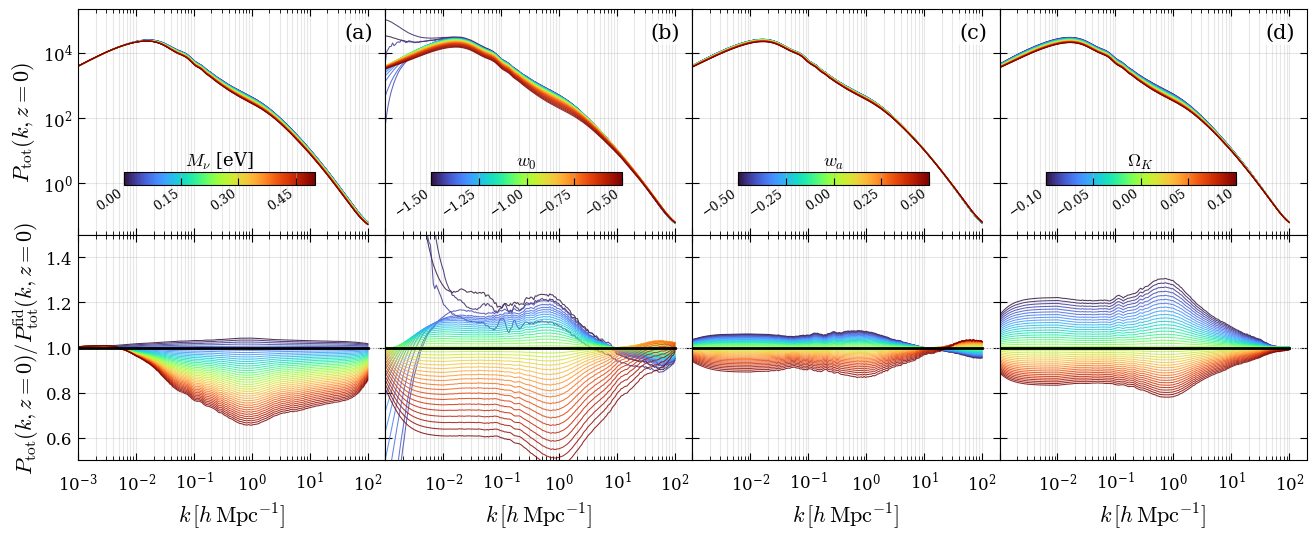

[Warning] wa=-0.62 is out of range [-0.5, 0.5]
[Warning] wa=-0.54 is out of range [-0.5, 0.5]


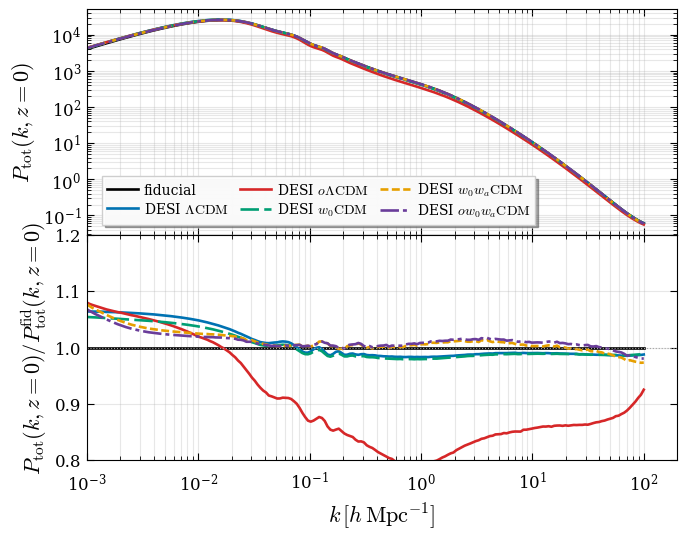

In [4]:
k_fid, pk_fid = emu.get_pk_total(fid, zred=z_pk, klist=klist_pk)

fig, axes = plt.subplots(
    2, 4, figsize=param_figure_size, sharex=True, sharey="row",
    gridspec_kw={"wspace": 0.0, "hspace": 0.0},
)

for col, (title, key, values) in enumerate(param_panels):
    ax_abs = axes[0, col]
    ax_ratio = axes[1, col]
    add_panel_label(ax_abs, panel_labels[col])
    norm, colors = param_color_scale(values)

    for value, color in zip(values, colors):
        p = set_demo_param(**{key: value})
        k, pk = emu.get_pk_total(p, zred=z_pk, klist=klist_pk)
        style = param_line_style(color)
        ax_abs.loglog(k, pk, **style)
        ax_ratio.semilogx(k, pk / pk_fid, **style)

    ax_ratio.semilogx(k_fid, np.ones_like(pk_fid), color="k", lw=2.0, zorder=4)
    add_param_colorbar(ax_abs, title, norm, side="pk")
    ax_ratio.axhline(1.0, color="0.65", lw=0.8, ls=":")

for ax in axes[1, :]:
    ax.set_ylim(*ratio_ylim)
for ax in axes.flat:
    ax.set_xlim(1.0e-3, 2.0e2)
format_panel_axes(axes)

for ax in axes[1, :]:
    ax.tick_params(labelbottom=True)

axes[0, 0].set_ylabel(r"$P_{\rm tot}(k,z=0)$", fontsize=16)
axes[1, 0].set_ylabel(r"$P_{\rm tot}(k,z=0)/P_{\rm tot}^{\rm fid}(k,z=0)$", fontsize=16)
for ax in axes[1, :]:
    ax.set_xlabel(r"$k\,[h\,{\rm Mpc}^{-1}]$", fontsize=16, labelpad=5)
for ax in axes[1, 1:]:
    for tick, tick_label in zip(ax.get_xticks(), ax.get_xticklabels()):
        if tick > 0 and np.isclose(np.log10(tick), -3.0):
            tick_label.set_visible(False)
fig.subplots_adjust(left=0.085, right=0.995, bottom=0.16, top=0.98, wspace=0.0, hspace=0.0)
if save_pdf:
    plt.savefig("demo_extended_pk.pdf", bbox_inches="tight", dpi=200)
plt.show()

fig, axes = plt.subplots(
    2, 1, figsize=scenario_figure_size, sharex=True,
    gridspec_kw={"hspace": 0.0},
)
ax_abs, ax_ratio = axes
for (label, updates, strict), color, ls in zip(scenario_panels, scenario_colors, scenario_linestyles):
    p = set_demo_param(strict=strict, **updates)
    k, pk = emu.get_pk_total(p, zred=z_pk, klist=klist_pk)
    ax_abs.loglog(k, pk, color=color, ls=ls, lw=1.9, label=label)
    ax_ratio.semilogx(k, pk / pk_fid, color=color, ls=ls, lw=1.9)

add_scenario_legend(ax_abs, loc="lower left", bbox_to_anchor=(0.02, 0.03))
ax_ratio.axhline(1.0, color="0.65", lw=0.8, ls=":")
ax_ratio.set_ylim(*pk_scenario_ratio_ylim)
for ax in axes:
    ax.set_xlim(1.0e-3, 2.0e2)
format_panel_axes(axes[:, np.newaxis])
ax_ratio.tick_params(labelbottom=True)

ax_abs.set_ylabel(r"$P_{\rm tot}(k,z=0)$", fontsize=16)
ax_ratio.set_ylabel(r"$P_{\rm tot}(k,z=0)/P_{\rm tot}^{\rm fid}(k,z=0)$", fontsize=16)
ax_ratio.set_xlabel(r"$k\,[h\,{\rm Mpc}^{-1}]$", fontsize=16, labelpad=5)
fig.subplots_adjust(left=0.16, right=0.98, bottom=0.16, top=0.98, hspace=0.0)
if save_pdf:
    plt.savefig("demo_extended_pk_desi.pdf", bbox_inches="tight", dpi=200)
plt.show()

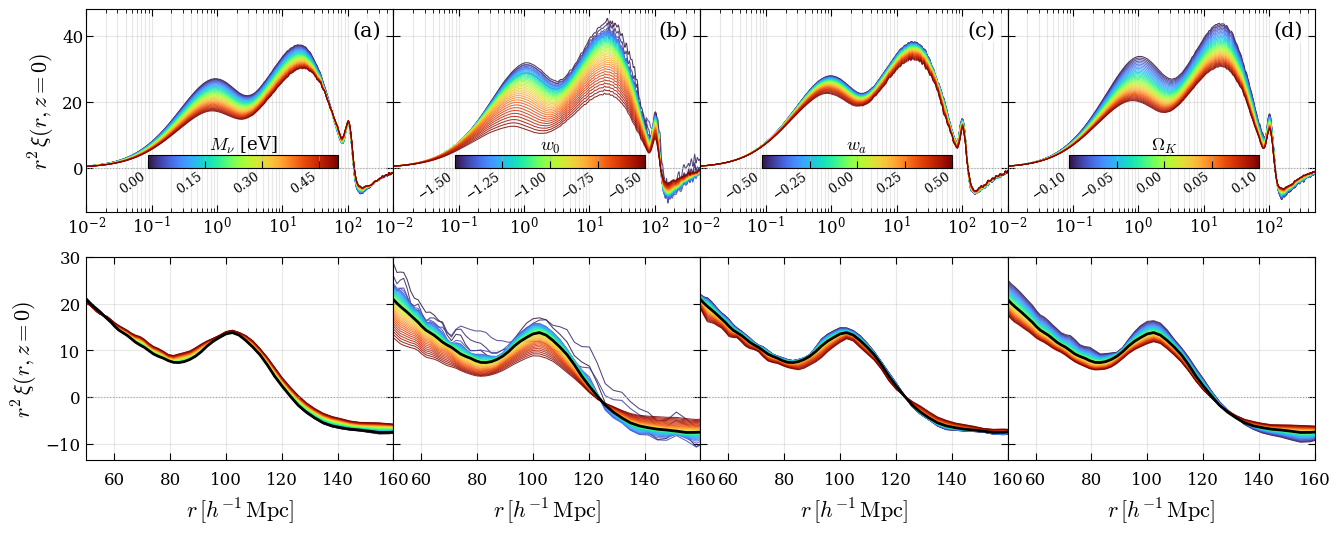

[Warning] wa=-0.62 is out of range [-0.5, 0.5]
[Warning] wa=-0.54 is out of range [-0.5, 0.5]


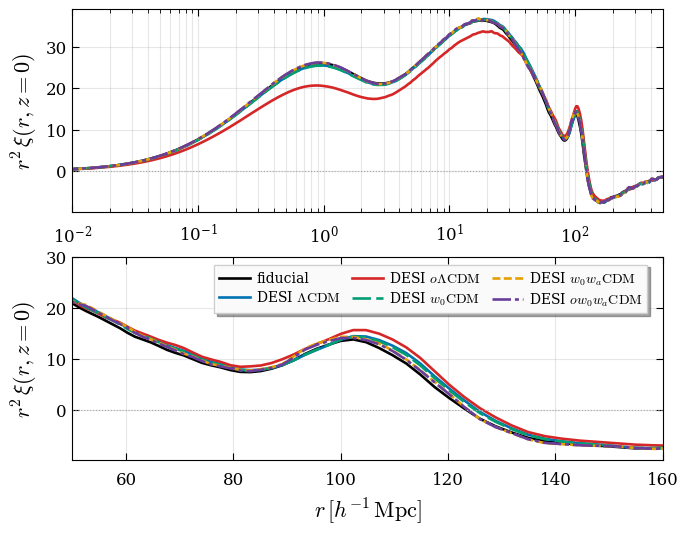

In [5]:
r_fid, xi_fid = emu.get_xi(fid, zred=z_pk, pk_type="total")

fig, axes = plt.subplots(
    2, 4, figsize=param_figure_size, sharex="row", sharey="row",
    gridspec_kw={"wspace": 0.0, "hspace": 0.22},
)

for col, (title, key, values) in enumerate(param_panels):
    ax_abs = axes[0, col]
    ax_zoom = axes[1, col]
    add_panel_label(ax_abs, panel_labels[col])
    norm, colors = param_color_scale(values)

    for value, color in zip(values, colors):
        p = set_demo_param(**{key: value})
        r, xi = emu.get_xi(p, zred=z_pk, pk_type="total")
        xi_plot = r**2 * xi
        style = param_line_style(color)
        ax_abs.semilogx(r, xi_plot, **style)
        ax_zoom.plot(r, xi_plot, **style)

    ax_zoom.plot(r_fid, r_fid**2 * xi_fid, color="k", lw=2.0, zorder=4)
    add_param_colorbar(ax_abs, title, norm, side="xi")
    ax_abs.axhline(0.0, color="0.65", lw=0.8, ls=":")
    ax_zoom.axhline(0.0, color="0.65", lw=0.8, ls=":")

for ax in axes[0, :]:
    ax.set_xlim(1.0e-2, 5.0e2)
for ax in axes[1, :]:
    ax.set_xlim(5.0e1, 1.6e2)
    ax.set_ylim(top=30.0)
format_panel_axes(axes)

for ax in axes[0, :]:
    ax.tick_params(labeltop=False, labelbottom=True, pad=2)
for ax in axes[1, :]:
    ax.tick_params(labelbottom=True)

axes[0, 0].set_ylabel(r"$r^2\,\xi(r,z=0)$", fontsize=16)
axes[1, 0].set_ylabel(r"$r^2\,\xi(r,z=0)$", fontsize=16)
for ax in axes[1, :]:
    ax.set_xlabel(r"$r\,[h^{-1}\,{\rm Mpc}]$", fontsize=16, labelpad=5)
fig.subplots_adjust(left=0.085, right=0.995, bottom=0.16, top=0.98, wspace=0.0, hspace=0.22)
if save_pdf:
    plt.savefig("demo_extended_xi.pdf", bbox_inches="tight", dpi=200)
plt.show()

fig, axes = plt.subplots(
    2, 1, figsize=scenario_figure_size, sharex="row",
    gridspec_kw={"hspace": 0.22},
)
ax_abs, ax_zoom = axes
for (label, updates, strict), color, ls in zip(scenario_panels, scenario_colors, scenario_linestyles):
    p = set_demo_param(strict=strict, **updates)
    r, xi = emu.get_xi(p, zred=z_pk, pk_type="total")
    xi_plot = r**2 * xi
    ax_abs.semilogx(r, xi_plot, color=color, ls=ls, lw=1.9, label=label)
    ax_zoom.plot(r, xi_plot, color=color, ls=ls, lw=1.9, label=label)

add_scenario_legend(ax_zoom, loc="upper right", bbox_to_anchor=(0.98, 0.98))
ax_abs.axhline(0.0, color="0.65", lw=0.8, ls=":")
ax_zoom.axhline(0.0, color="0.65", lw=0.8, ls=":")
ax_abs.set_xlim(1.0e-2, 5.0e2)
ax_zoom.set_xlim(5.0e1, 1.6e2)
ax_zoom.set_ylim(top=30.0)
format_panel_axes(axes[:, np.newaxis])

for ax in axes:
    ax.tick_params(labelbottom=True)

ax_abs.set_ylabel(r"$r^2\,\xi(r,z=0)$", fontsize=16)
ax_zoom.set_ylabel(r"$r^2\,\xi(r,z=0)$", fontsize=16)
ax_zoom.set_xlabel(r"$r\,[h^{-1}\,{\rm Mpc}]$", fontsize=16, labelpad=5)
fig.subplots_adjust(left=0.16, right=0.98, bottom=0.16, top=0.98, hspace=0.22)
if save_pdf:
    plt.savefig("demo_extended_xi_desi.pdf", bbox_inches="tight", dpi=200)
plt.show()

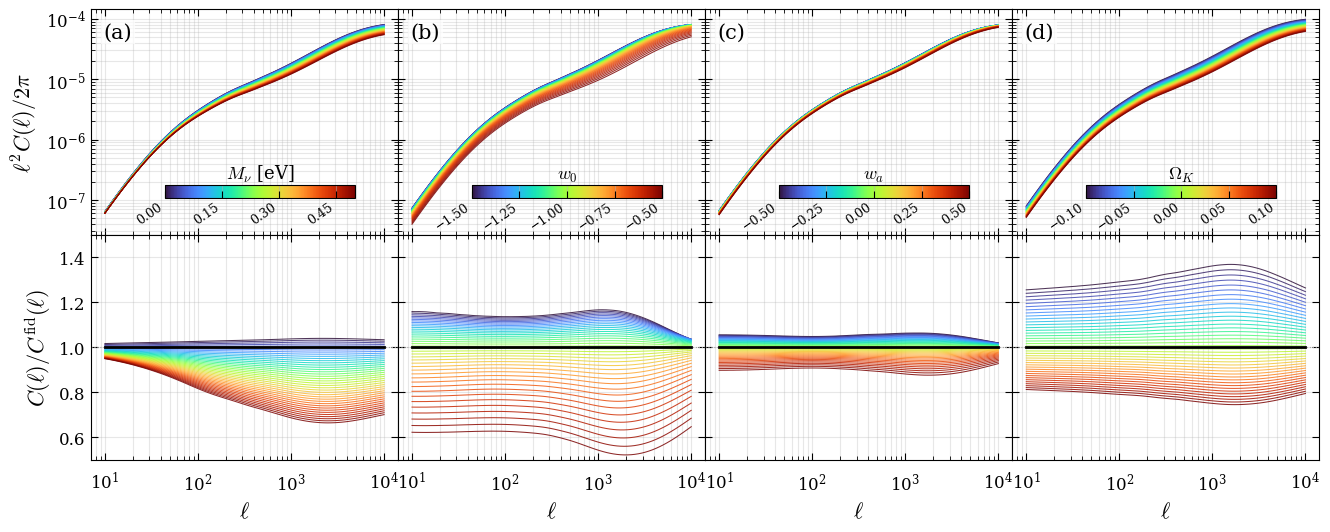

[Warning] wa=-0.62 is out of range [-0.5, 0.5]
[Warning] wa=-0.54 is out of range [-0.5, 0.5]


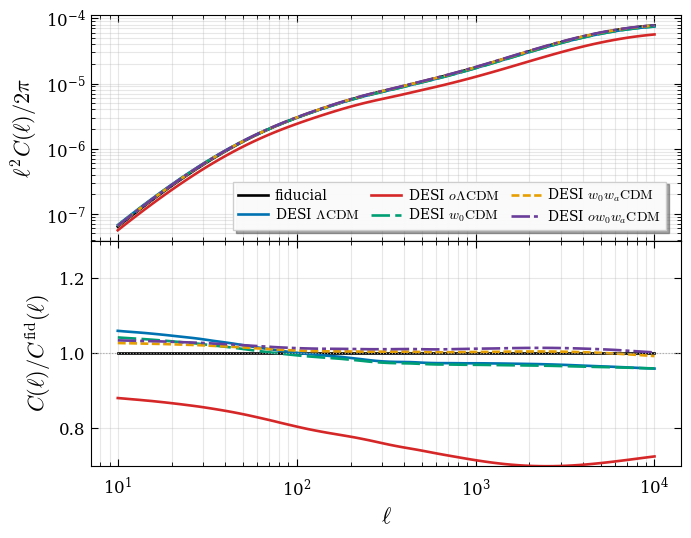

In [6]:
ell_fid, cl_fid = emu.get_cl_limber(
    fid, zlist=zlist_cl, klist=klist_cl, llist=llist_cl, src_dist=None
)

fig, axes = plt.subplots(
    2, 4, figsize=param_figure_size, sharex=True, sharey="row",
    gridspec_kw={"wspace": 0.0, "hspace": 0.0},
)

for col, (title, key, values) in enumerate(param_panels):
    ax_abs = axes[0, col]
    ax_ratio = axes[1, col]
    add_panel_label(ax_abs, panel_labels[col], loc="left")
    norm, colors = param_color_scale(values)

    for value, color in zip(values, colors):
        p = set_demo_param(**{key: value})
        ell, cl = emu.get_cl_limber(
            p, zlist=zlist_cl, klist=klist_cl, llist=llist_cl, src_dist=None
        )
        cl_plot = ell**2 * cl / (2.0 * np.pi)
        style = param_line_style(color)
        ax_abs.loglog(ell, cl_plot, **style)
        ax_ratio.semilogx(ell, cl / cl_fid, **style)

    ax_ratio.semilogx(ell_fid, np.ones_like(cl_fid), color="k", lw=2.0, zorder=4)
    add_param_colorbar(ax_abs, title, norm, side="right")
    ax_ratio.axhline(1.0, color="0.65", lw=0.8, ls=":")

for ax in axes[1, :]:
    ax.set_ylim(*ratio_ylim)
format_panel_axes(axes)

for ax in axes[1, :]:
    ax.tick_params(labelbottom=True)

axes[0, 0].set_ylabel(r"$\ell^2 C(\ell) / 2\pi$", fontsize=16)
axes[1, 0].set_ylabel(r"$C(\ell)/C^{\rm fid}(\ell)$", fontsize=16)
for ax in axes[1, :]:
    ax.set_xlabel(r"$\ell$", fontsize=16, labelpad=5)
fig.subplots_adjust(left=0.085, right=0.995, bottom=0.16, top=0.98, wspace=0.0, hspace=0.0)
if save_pdf:
    plt.savefig("demo_extended_cl.pdf", bbox_inches="tight", dpi=200)
plt.show()

fig, axes = plt.subplots(
    2, 1, figsize=scenario_figure_size, sharex=True,
    gridspec_kw={"hspace": 0.0},
)
ax_abs, ax_ratio = axes
for (label, updates, strict), color, ls in zip(scenario_panels, scenario_colors, scenario_linestyles):
    p = set_demo_param(strict=strict, **updates)
    ell, cl = emu.get_cl_limber(
        p, zlist=zlist_cl, klist=klist_cl, llist=llist_cl, src_dist=None
    )
    cl_plot = ell**2 * cl / (2.0 * np.pi)
    ax_abs.loglog(ell, cl_plot, color=color, ls=ls, lw=1.9, label=label)
    ax_ratio.semilogx(ell, cl / cl_fid, color=color, ls=ls, lw=1.9)

add_scenario_legend(ax_abs, loc="lower right", bbox_to_anchor=(0.98, 0.03))
ax_ratio.axhline(1.0, color="0.65", lw=0.8, ls=":")
ax_ratio.set_ylim(*cl_scenario_ratio_ylim)
format_panel_axes(axes[:, np.newaxis])
ax_ratio.tick_params(labelbottom=True)

ax_abs.set_ylabel(r"$\ell^2 C(\ell) / 2\pi$", fontsize=16)
ax_ratio.set_ylabel(r"$C(\ell)/C^{\rm fid}(\ell)$", fontsize=16)
ax_ratio.set_xlabel(r"$\ell$", fontsize=16, labelpad=5)
fig.subplots_adjust(left=0.16, right=0.98, bottom=0.16, top=0.98, hspace=0.0)
if save_pdf:
    plt.savefig("demo_extended_cl_desi.pdf", bbox_inches="tight", dpi=200)
plt.show()